## Importing Libraries

In [5]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


In this section, I am importing the essential libraries required for data manipulation, analysis, and machine learning tasks. Each library serves a specific purpose in the project, as detailed below:

**Purpose of Each Library:**

## Pandas (pd):

Purpose: Used for data manipulation and analysis.

Usage in Project: Reading datasets, merging dataframes, and handling missing values.

## NumPy (np):

Purpose: Provides support for large, multi-dimensional arrays and matrices.
Usage in Project: Efficient numerical computations and handling arrays.

Scikit-Learn (sklearn):

Purpose: A machine learning library for Python.

# Modules Imported:

**train_test_split:** To split the dataset into training and testing sets.

**cross_val_score:** For cross-validation to assess the model's performance.

**GridSearchCV:** To perform hyperparameter tuning.

**StandardScaler:** For feature scaling to standardize the dataset.

**RandomForestRegressor:** To build the predictive model.

**RFE:** For feature selection using Recursive Feature Elimination.

**mean_squared_error:** To evaluate the model's performance by calculating the mean squared error.

# Matplotlib (plt):

Purpose: A plotting library for creating static, animated, and interactive visualizations.
Usage in Project: To visualize feature importance and other relevant plots.

## Loading Dataset

In [6]:
import os
print(os.getcwd())

c:\Users\Hamza Ikraam\Desktop\Projects\New folder\Pharmaceutical-Inventory-Demand-Forecasting-using-Machine-Learning-main\notebooks


In [7]:
print("Loading datasets...")
fact_medicine_stock = pd.read_csv("../data/medicine_stock.csv")
dim_medicine = pd.read_csv("../data/medicines.csv")


Loading datasets...


In [8]:
fact_medicine_stock.head()

,Year,Month,State,District,City,Facility_Category,Facility_Type,Facility_Name,Medicine_Name,Opening_Stock,Received,Consumption,Expired,Wasted,Lost,Closing_Stock,Nearing_Expiry,Reorder_Level
0,2024,January,Gujarat,Nagpur,Pune,PPP,Clinic,Sahyadri Hospital,Amoxicillin,1962,231,298,40,20,15,1820,7,296
1,2024,February,Tamil Nadu,Bangalore,Kochi,Central,Health Center,Sahyadri Hospital,Amoxicillin,296,320,130,93,13,59,321,15,403
2,2024,March,Tamil Nadu,Ahmedabad,Kochi,Central,Lab,Sahyadri Hospital,Amoxicillin,1674,344,73,23,43,41,1838,20,465
3,2024,April,Tamil Nadu,Mumbai,Mumbai,Central,Clinic,Sahyadri Hospital,Amoxicillin,379,148,297,63,40,42,85,10,309
4,2024,May,Karnataka,Mysore,Nagpur,Central,Hospital,Sahyadri Hospital,Amoxicillin,775,326,213,53,22,43,770,5,277


In [9]:
dim_medicine.head()

,Category,Brand,Type,SubType,Medicine_Name
0,EML,Generic,Antipyretic,Ibuprofen,Flagyl
1,AML,Generic,Antipyretic,Cephalosporin,Ciprofloxacin
2,EML,Branded,Antipyretic,Penicillin,Augmentin
3,EML,Generic,Antiviral,Penicillin,Ciprofloxacin
4,AML,Branded,Antipyretic,Cephalosporin,Levofloxacin


In [10]:
fact_medicine_stock.info()

<class 'pandas.DataFrame'>
RangeIndex: 14700 entries, 0 to 14699
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Year               14700 non-null  int64
 1   Month              14700 non-null  str  
 2   State              14700 non-null  str  
 3   District           14700 non-null  str  
 4   City               14700 non-null  str  
 5   Facility_Category  14700 non-null  str  
 6   Facility_Type      14700 non-null  str  
 7   Facility_Name      14700 non-null  str  
 8   Medicine_Name      14700 non-null  str  
 9   Opening_Stock      14700 non-null  int64
 10  Received           14700 non-null  int64
 11  Consumption        14700 non-null  int64
 12  Expired            14700 non-null  int64
 13  Wasted             14700 non-null  int64
 14  Lost               14700 non-null  int64
 15  Closing_Stock      14700 non-null  int64
 16  Nearing_Expiry     14700 non-null  int64
 17  Reorder_Level      1470

In [11]:
dim_medicine.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Category       50 non-null     str  
 1   Brand          50 non-null     str  
 2   Type           50 non-null     str  
 3   SubType        50 non-null     str  
 4   Medicine_Name  50 non-null     str  
dtypes: str(5)
memory usage: 4.0 KB


**Merging Datasets**

In [12]:
print("Merging datasets...")
merged_data = pd.merge(fact_medicine_stock, dim_medicine, on='Medicine_Name', how='left')


Merging datasets...


In [13]:
# Convert Month to datetime format for easier plotting
merged_data['Date'] = pd.to_datetime(merged_data['Year'].astype(str) + '-' + merged_data['Month'].astype(str))


C:\Users\Hamza Ikraam\AppData\Local\Temp\ipykernel_18912\3767067292.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_data['Date'] = pd.to_datetime(merged_data['Year'].astype(str) + '-' + merged_data['Month'].astype(str))


## Feature Engineering

**Creating lag features and rolling statistics**

In [14]:
print("Creating lag features and rolling statistics...")
for lag in range(1, 4):
    merged_data[f'Lag_{lag}_Closing_Stock'] = merged_data.groupby('Medicine_Name')['Closing_Stock'].shift(lag)
    merged_data[f'Lag_{lag}_Consumption'] = merged_data.groupby('Medicine_Name')['Consumption'].shift(lag)
    merged_data[f'Lag_{lag}_Received'] = merged_data.groupby('Medicine_Name')['Received'].shift(lag)

# Rolling statistics
merged_data['Rolling_Mean_3'] = merged_data.groupby('Medicine_Name')['Closing_Stock'].transform(lambda x: x.rolling(window=3).mean())
merged_data['Rolling_Sum_3'] = merged_data.groupby('Medicine_Name')['Closing_Stock'].transform(lambda x: x.rolling(window=3).sum())

merged_data.dropna(inplace=True)


Creating lag features and rolling statistics...


**Lag Features:**

- I created lagged versions of Closing_Stock, Consumption, and Received for the previous 1, 2, and 3 months.
- This helps capture historical data points, allowing me to understand trends and make predictions based on past values.

**Rolling Statistics:**

- I calculated the rolling mean and rolling sum of Closing_Stock over a 3-month window.
- These statistics smooth out short-term fluctuations, providing a clearer view of longer-term trends, which is useful for making more accurate predictions.

**Drop NaN Values:**

- I removed rows with NaN values generated due to shifting.
- This ensures the dataset is clean and ready for modeling without missing data issues.







In [15]:
print("Fact Medicine Stock Data Description:")
fact_medicine_stock.describe()



Fact Medicine Stock Data Description:


,Year,Opening_Stock,Received,Consumption,Expired,Wasted,Lost,Closing_Stock,Nearing_Expiry,Reorder_Level
count,14700.0,14700.000000,14700.000000,14700.000000,14700.000000,14700.000000,14700.000000,14700.000000,14700.000000,14700.000000
mean,2024.0,1097.896939,273.996054,274.612245,54.443810,54.506190,54.599932,892.767007,26.967075,325.520748
std,0.0,515.859619,129.920137,129.799644,25.936442,26.079309,26.018642,568.379020,12.971031,101.083480
min,2024.0,100.000000,50.000000,50.000000,10.000000,10.000000,10.000000,0.000000,5.000000,150.000000
25%,2024.0,669.000000,162.000000,162.000000,32.000000,32.000000,32.000000,407.750000,16.000000,238.000000
50%,2024.0,1101.000000,275.000000,275.000000,54.000000,55.000000,55.000000,886.000000,27.000000,326.000000
75%,2024.0,1528.000000,386.000000,387.000000,77.000000,77.000000,77.000000,1366.000000,38.000000,412.000000
max,2024.0,1999.000000,499.000000,499.000000,99.000000,99.000000,99.000000,2264.000000,49.000000,499.000000


In [16]:
print("Dim Medicine Data Description:")
dim_medicine.describe()

Dim Medicine Data Description:


,Category,Brand,Type,SubType,Medicine_Name
count,50,50,50,50,50
unique,2,2,5,7,30
top,AML,Generic,Painkiller,Cephalosporin,Neosporin
freq,27,26,15,11,4


In [17]:
print("\nMissing Values in Fact Medicine Stock Data:")
print(fact_medicine_stock.isnull().sum())
print("\nMissing Values in Dim Medicine Data:")
print(dim_medicine.isnull().sum())



Missing Values in Fact Medicine Stock Data:
Year                 0
Month                0
State                0
District             0
City                 0
Facility_Category    0
Facility_Type        0
Facility_Name        0
Medicine_Name        0
Opening_Stock        0
Received             0
Consumption          0
Expired              0
Wasted               0
Lost                 0
Closing_Stock        0
Nearing_Expiry       0
Reorder_Level        0
dtype: int64

Missing Values in Dim Medicine Data:
Category         0
Brand            0
Type             0
SubType          0
Medicine_Name    0
dtype: int64


## Exploratory Data Analysis

**Analyzing stock trends**

Analyzing stock trends...


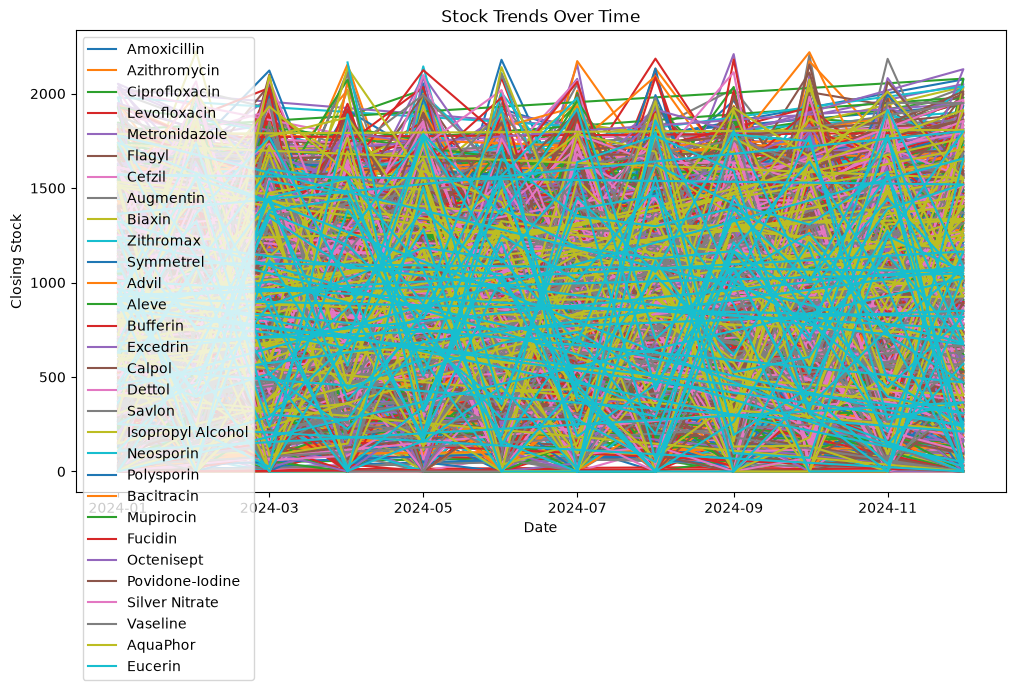

In [18]:
print("Analyzing stock trends...")
plt.figure(figsize=(12, 6))
for medicine in merged_data['Medicine_Name'].unique():
    subset = merged_data[merged_data['Medicine_Name'] == medicine]
    plt.plot(subset['Date'], subset['Closing_Stock'], label=medicine)

plt.xlabel('Date')
plt.ylabel('Closing Stock')
plt.title('Stock Trends Over Time')
plt.legend(loc='upper left')
plt.show()


**Visualization:**
- I plotted the Closing_Stock of each medicine over time.
- Each line represents the stock levels of a different medicine, allowing me to compare trends and patterns.

**Trend Identification:**

- By analyzing the plotted graph, I can observe the fluctuations and trends in the stock levels of various medicines over time.
- I might notice seasonal trends, periods of high or low stock, and identify medicines with consistently high or low stock levels.

**Patterns:**

- Some medicines may show cyclical patterns, indicating regular restocking or consumption.
- Sudden drops or spikes could indicate supply chain issues or sudden changes in demand.

**Analyzing rolling statistics**

Analyzing rolling statistics...


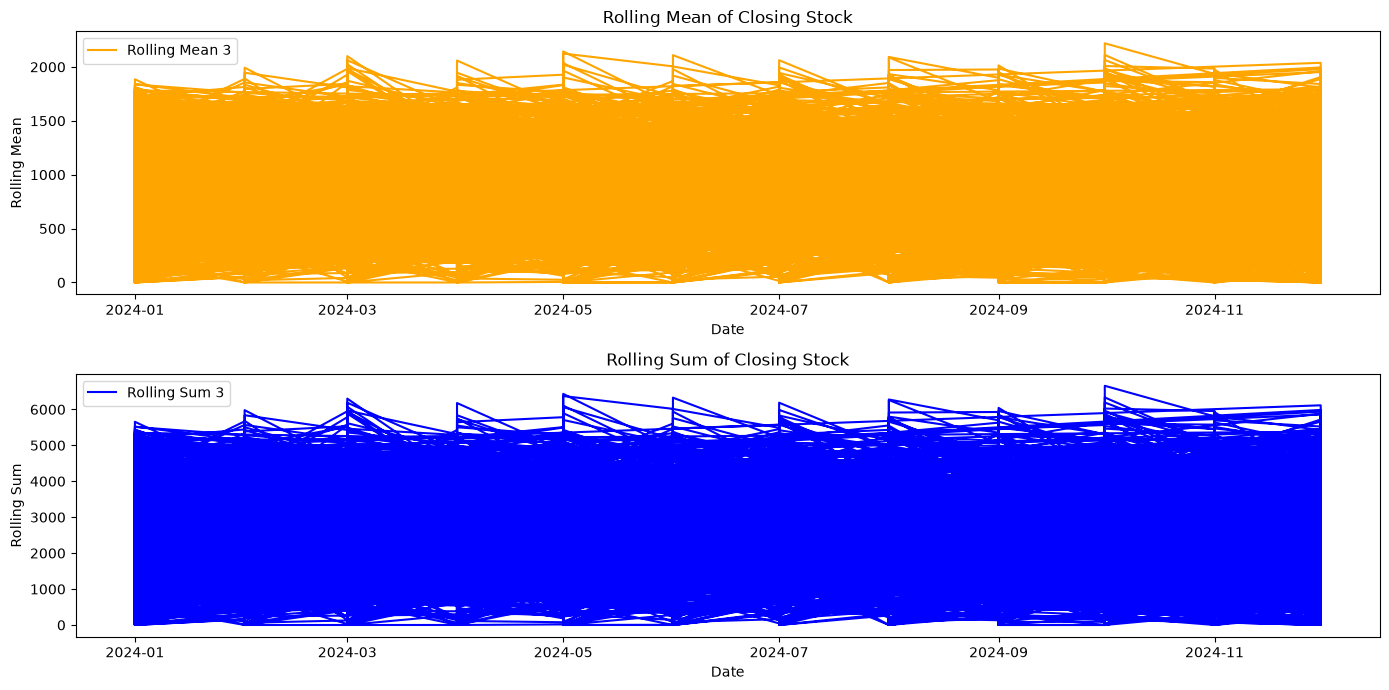

In [19]:
print("Analyzing rolling statistics...")
plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)
plt.plot(merged_data['Date'], merged_data['Rolling_Mean_3'], label='Rolling Mean 3', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Mean')
plt.title('Rolling Mean of Closing Stock')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(merged_data['Date'], merged_data['Rolling_Sum_3'], label='Rolling Sum 3', color='blue')
plt.xlabel('Date')
plt.ylabel('Rolling Sum')
plt.title('Rolling Sum of Closing Stock')
plt.legend()

plt.tight_layout()
plt.show()


**Analyzing categorical features**

Analyzing categorical features...


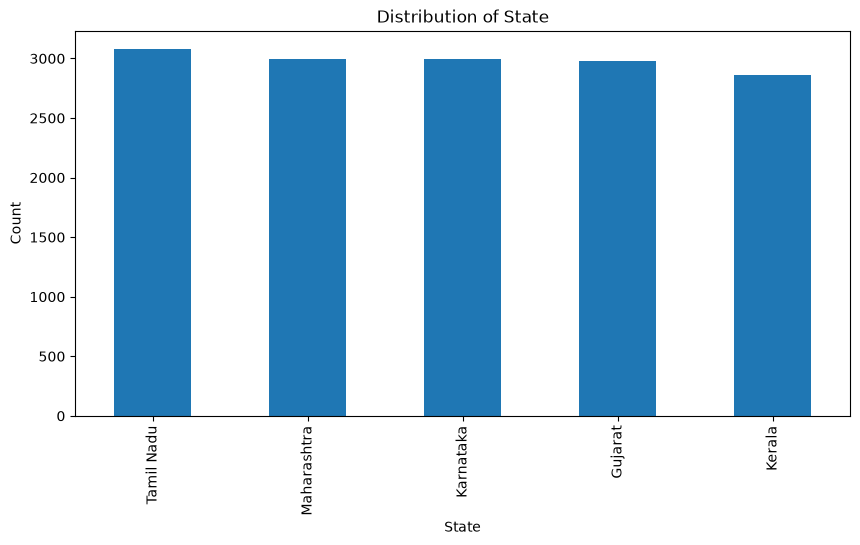

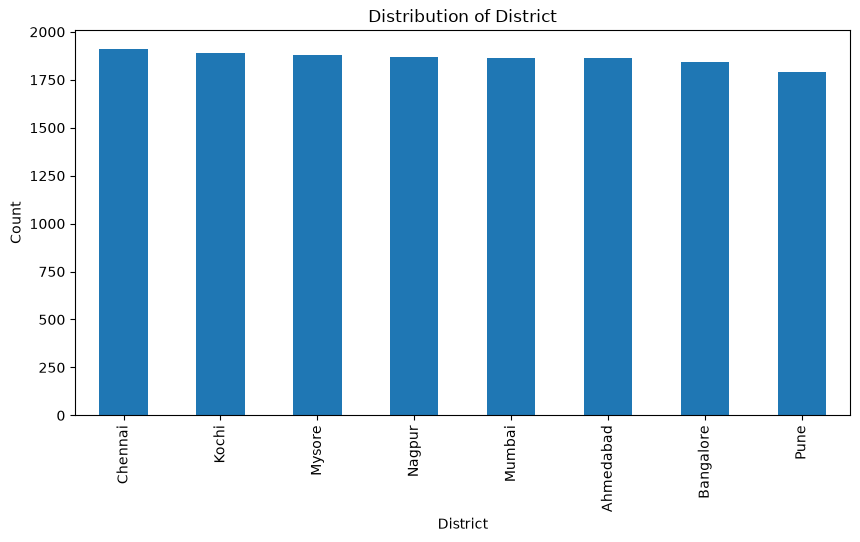

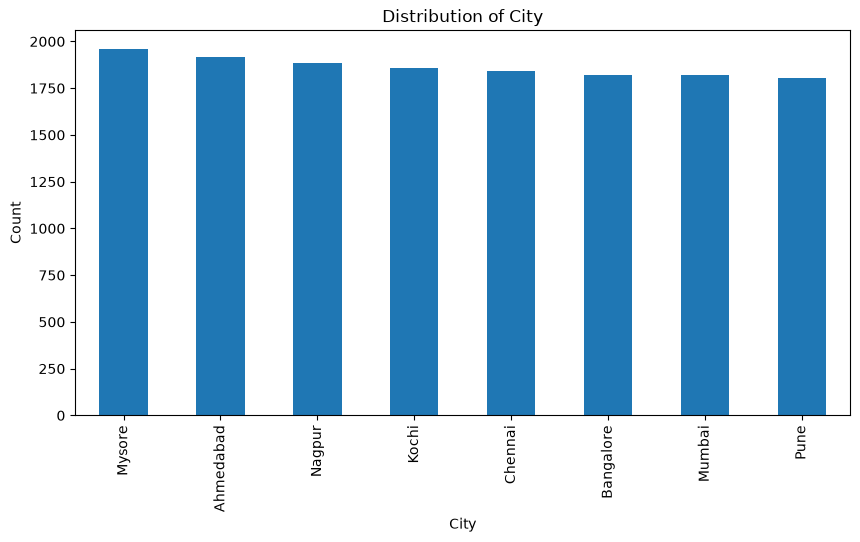

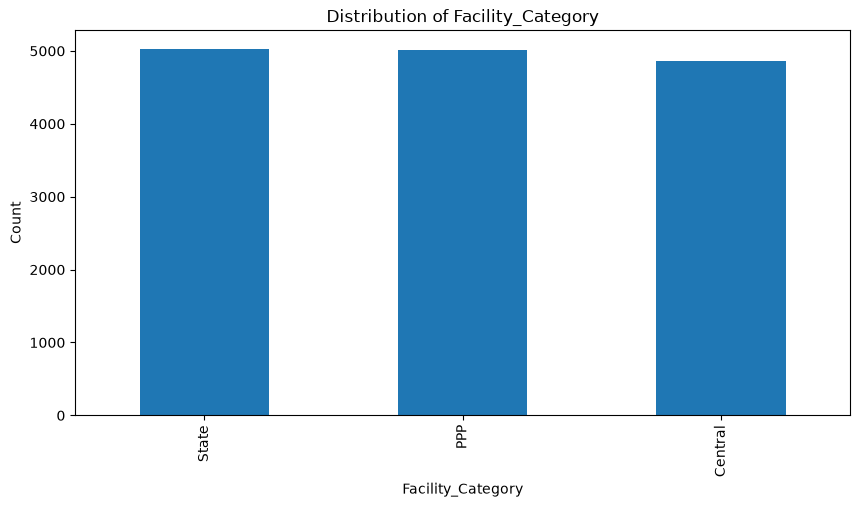

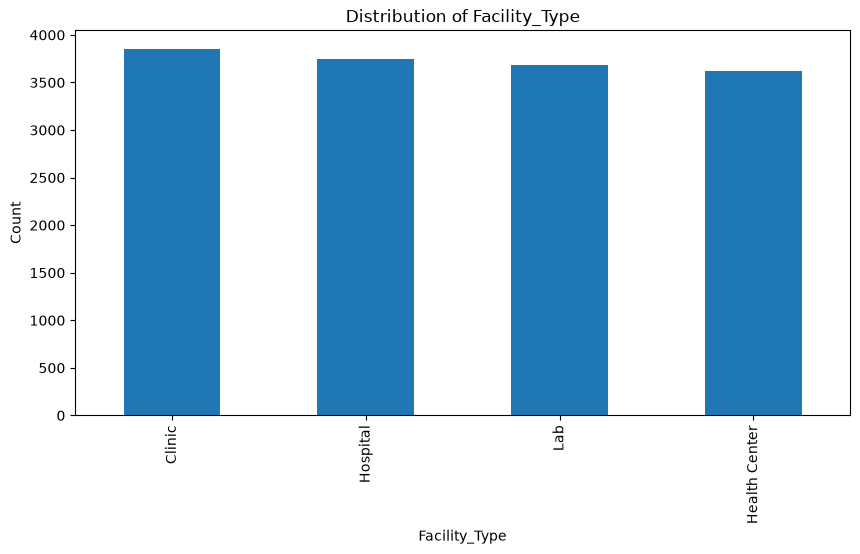

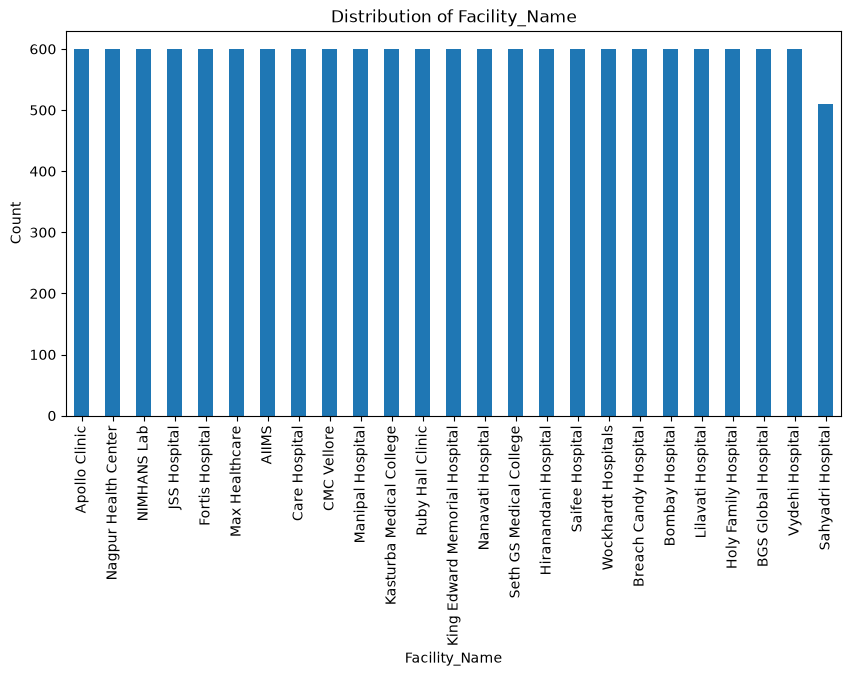

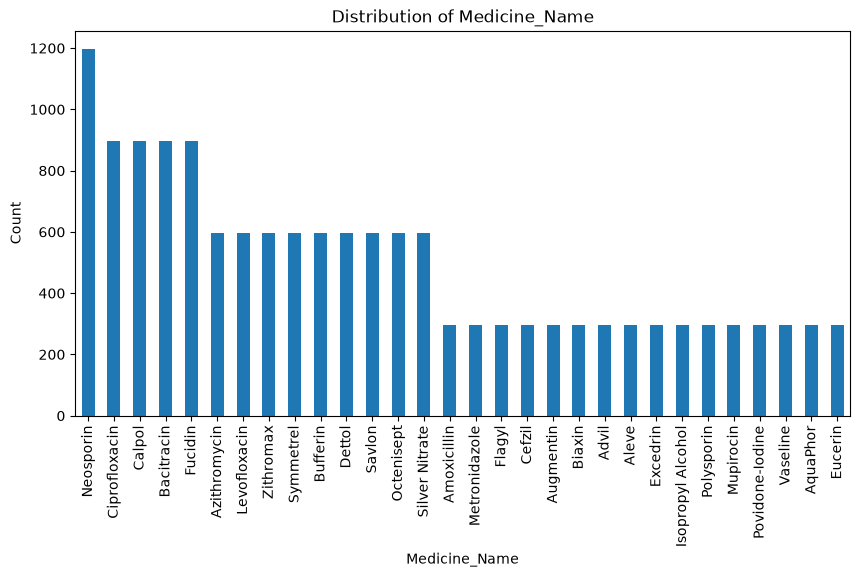

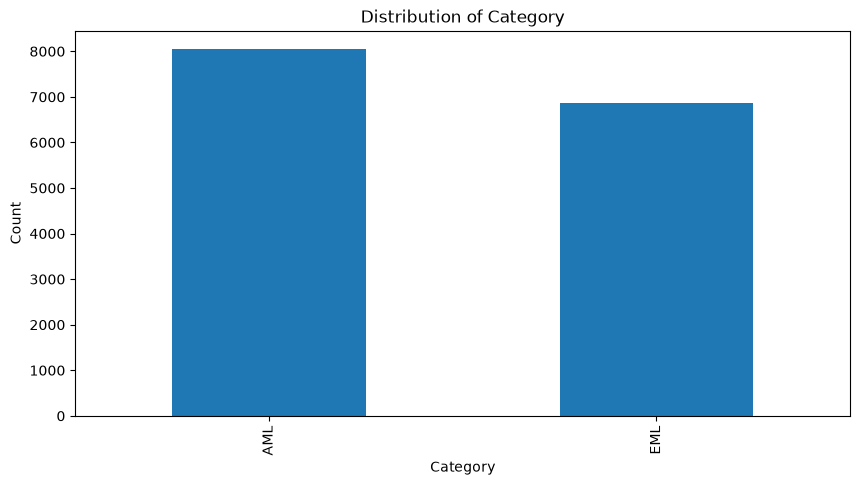

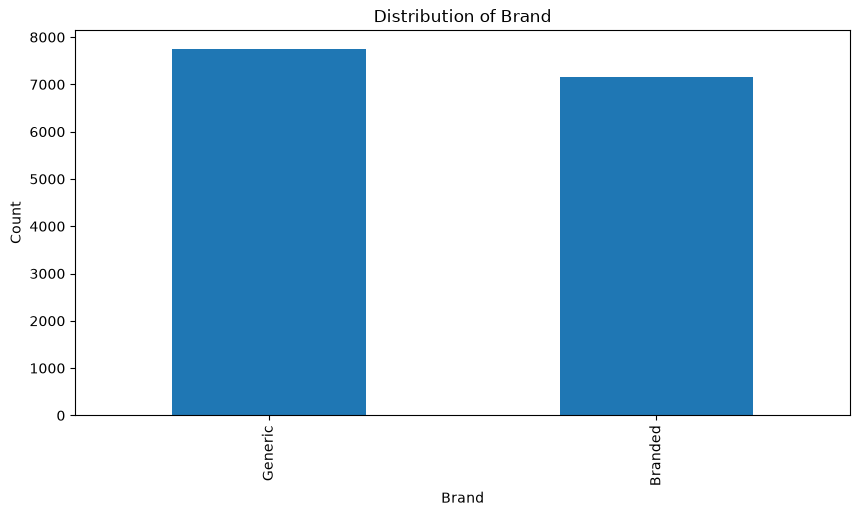

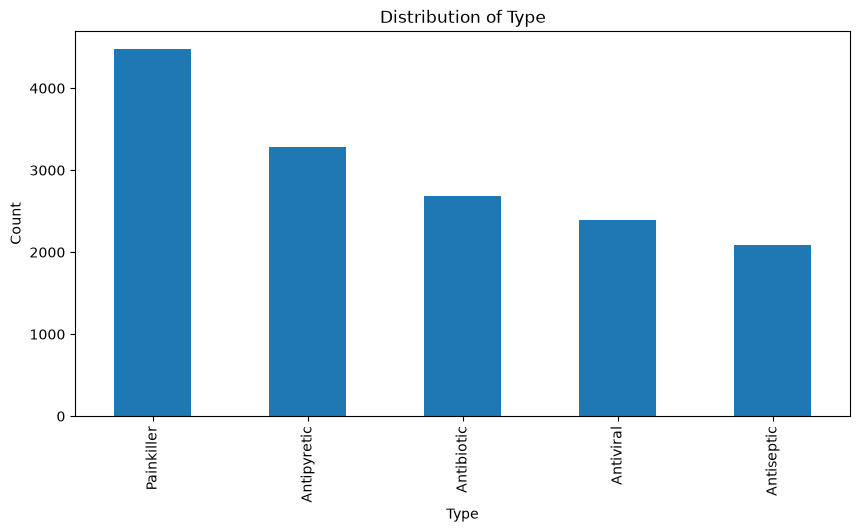

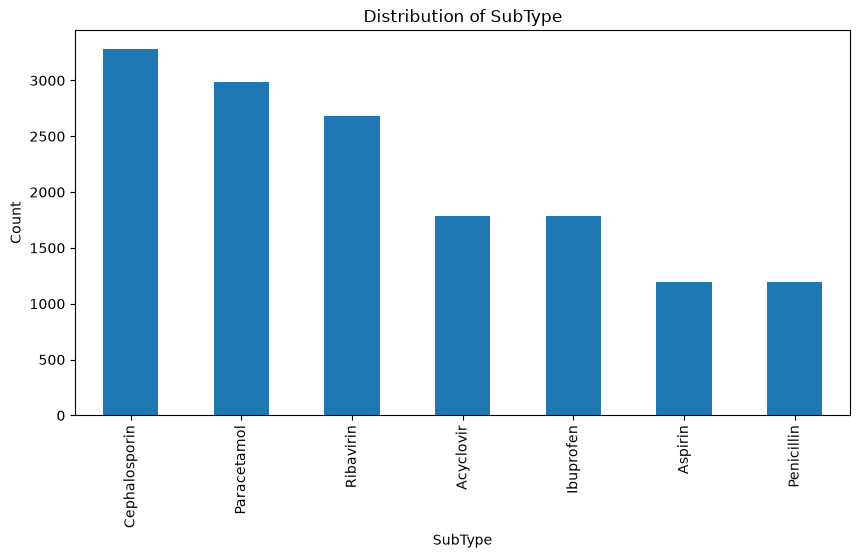

In [20]:
print("Analyzing categorical features...")
categorical_features = ['State', 'District', 'City', 'Facility_Category', 'Facility_Type', 'Facility_Name',
                        'Medicine_Name', 'Category', 'Brand', 'Type', 'SubType']

for col in categorical_features:
    plt.figure(figsize=(10, 5))
    merged_data[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


**Prepare Data for Modeling**

In [21]:
print("Preparing data for modeling...")
encoded_data = pd.get_dummies(merged_data, columns=categorical_features)
encoded_data['Month'] = merged_data['Date'].dt.month
encoded_data['Year'] = merged_data['Date'].dt.year

# Select Features and Target Variable
features = [col for col in encoded_data.columns if col != 'Closing_Stock' and col != 'Date']
target = 'Closing_Stock'

X = encoded_data[features]
y = encoded_data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Preparing data for modeling...


**Feature Scaling**

In [22]:
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Scaling features...


**Feature Selection with RFE**

In [23]:
print("Selecting features with RFE...")
rfe_model = RandomForestRegressor(n_estimators=10, random_state=42)
rfe = RFE(estimator=rfe_model, n_features_to_select=20)
rfe.fit(X_train_scaled, y_train)

# Selected Features
selected_features = X_train.columns[rfe.support_]
print(f'Selected Features: {selected_features}')


Selecting features with RFE...
Selected Features: Index(['Month', 'Opening_Stock', 'Received', 'Consumption', 'Expired',
       'Wasted', 'Lost', 'Nearing_Expiry', 'Reorder_Level',
       'Lag_1_Closing_Stock', 'Lag_1_Consumption', 'Lag_1_Received',
       'Lag_2_Closing_Stock', 'Lag_2_Consumption', 'Lag_2_Received',
       'Lag_3_Closing_Stock', 'Lag_3_Consumption', 'Lag_3_Received',
       'Rolling_Mean_3', 'Rolling_Sum_3'],
      dtype='str')


## Model Building

In [24]:
X_train_selected = X_train_scaled[:, rfe.support_]
X_test_selected = X_test_scaled[:, rfe.support_]

print("Training final model...")
final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(X_train_selected, y_train)


Training final model...


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

**Prediction and evaluation of model**

Evaluating model...
Mean Squared Error: 13066.096256874582
Plotting feature importance...


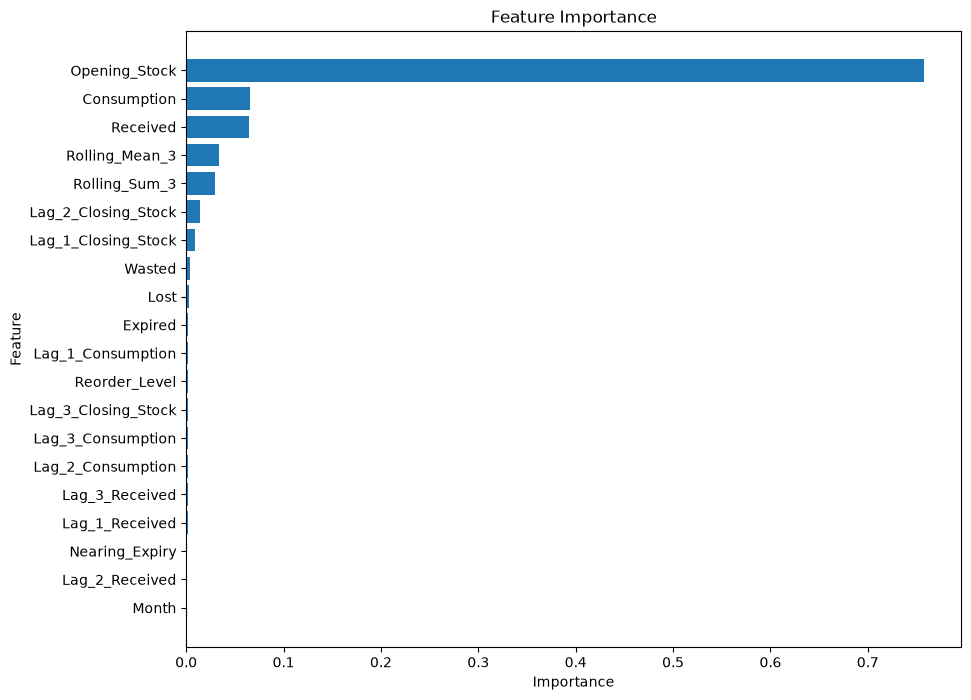

In [25]:
print("Evaluating model...")
y_pred = final_model.predict(X_test_selected)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Feature Importance
print("Plotting feature importance...")
feature_importances = final_model.feature_importances_
features_df = pd.DataFrame({'Feature': selected_features, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(features_df['Feature'], features_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()


**Optimization with Cross Validation and Hyperparamater Tuning**

In [29]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

final_model = RandomForestRegressor(n_estimators=10, random_state=42)

# Cross-Validation
print("Performing cross-validation...")
cv_scores = cross_val_score(final_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
print(f'Cross-Validation MSE Scores: {-cv_scores}')
print(f'Average Cross-Validation MSE: {-cv_scores.mean()}')

# Hyperparameter Tuning
print("Performing hyperparameter tuning with GridSearchCV...")
param_grid = {
    'n_estimators': [10],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}


grid_search = GridSearchCV(estimator=final_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV Score: {-grid_search.best_score_}')

# Train Optimized Model
final_model_optimized = grid_search.best_estimator_
final_model_optimized.fit(X_train_scaled, y_train)

# Evaluate Optimized Model
print("Evaluating optimized model...")
y_pred_optimized = final_model_optimized.predict(X_test_scaled)
mse_optimized = mean_squared_error(y_test, y_pred_optimized)
print(f'Optimized Mean Squared Error: {mse_optimized}')


prediction_df = pd.DataFrame({
    "Actual Closing Stock": y_test.values,
    "Predicted Closing Stock": y_pred_optimized
})

prediction_df["Error"] = (
    prediction_df["Actual Closing Stock"]
    - prediction_df["Predicted Closing Stock"]
)

prediction_df.to_csv("predictions.csv", index=False)

print("predictions.csv saved successfully!")





feature_names = X_train.columns.tolist()
joblib.dump(feature_names, "feature_names.pkl")


Performing cross-validation...
Cross-Validation MSE Scores: [16060.97436295 14955.39736798 18270.75236379 14630.57840671
 12942.97618868]
Average Cross-Validation MSE: 15372.135738021407
Performing hyperparameter tuning with GridSearchCV...
Best Parameters: {'max_depth': 30, 'min_samples_split': 5, 'n_estimators': 10}
Best CV Score: 15325.277643911357
Evaluating optimized model...
Optimized Mean Squared Error: 15201.282754819547
predictions.csv saved successfully!


['feature_names.pkl']

**Model Performance**

In [30]:
import numpy as np

variance_actual = np.var(y_test)
optimized_mse = 15201.282754819547
r2_score_optimized = 1 - (optimized_mse / variance_actual)
accuracy_percentage = r2_score_optimized * 100

print(f'Optimized Model R² Score: {r2_score_optimized:.2f}')
print(f'Optimized Model Accuracy: {accuracy_percentage:.2f}%')


Optimized Model R² Score: 0.95
Optimized Model Accuracy: 95.37%


In [31]:
# Save the optimized model
joblib.dump(final_model_optimized, "model.pkl")

# Save the fitted scaler
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
